In [ ]:
from google.colab import drive

# This line mounts my Google Drive to the current session in Google Colab
drive.mount('/content/drive')


import pandas as pd

# Define the path to the file in my Google Drive
file_path = '/content/drive/My Drive/Merge.csv'


# Read the CSV file from the specified path with the specified encoding
data = pd.read_csv(file_path, encoding='ISO-8859-1')

Mounted at /content/drive


In [ ]:
# Read the CSV file from the specified path, using the specified encoding and treating the first row as the header
data = pd.read_csv(file_path, encoding='ISO-8859-1', header=0)


In [ ]:
# Print the names of the columns in the DataFrame
print(data.columns)


Index(['Comment', 'Like', 'Reply'], dtype='object')


In [ ]:
print(data.head()) # Display the first few rows of the DataFrame


                                             Comment  Like  Reply
0  Your story is important Let's keep the convers...   3.0    1.0
1  Remember  darkness passes and the light return...   3.0    1.0
2          You are not alone We are in this together   3.0    1.0
3          Your strength is an inspiration to others   3.0    1.0
4  Every new day is  fresh start Keep pushing for...   3.0    1.0


⏬   **Data Preprocessing**

In [ ]:
# Remove any leading or trailing whitespace characters from the column names

data.columns = [col.strip() for col in data.columns]


In [ ]:
import re

# Importing the 're' library to work with Regular Expressions in Python.
# Regular Expressions (regex) are powerful tools for pattern matching and text processing.
# This library allows us to define complex patterns of characters and check if specific strings match these patterns.
# Common uses include searching for patterns in text, splitting strings based on patterns, and replacing parts of strings.


file_path = '/content/drive/My Drive/Merge.csv'


## Load data from CSV file using pandas with specified encoding
data = pd.read_csv(file_path, encoding='ISO-8859-1', header=0)


# Setting the encoding to 'ISO-8859-1', also known as Latin-1.
# This encoding is used to ensure correct handling of Western European characters that are not covered by the basic ASCII encoding.
# It includes characters with accents and other diacritical marks which are common in languages like French, Spanish, and German.
# Using this encoding can help avoid issues with character misrepresentation in data processing.


In [ ]:
from collections import Counter
# Importing the Counter class from the collections module.
# Counter is a specialized dictionary used for counting hashable objects, essentially providing a tally of objects.
# It is useful for quickly counting items in lists, analyzing frequency of elements, and for implementing algorithms that need element counting functionality.


# Define a function to clean text, preserving numbers and letters while removing other symbols
def clean_text(text):
    if not isinstance(text, str):
        return ""  # Return an empty string for non-string inputs
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'[^\w\s]', '', text)  # Remove symbols, but keep letters and numbers
    text = text.lower()  # Convert to lowercase
    return text

# Ensure there are no null values in 'Comment' or replace them with an empty string
data['Comment'].fillna('', inplace=True)  # Replaces nulls with empty string

# Apply the cleaning function to the 'Coment' column
data['Comment'] = data['Comment'].apply(clean_text)

# Create a list of all words in the 'cleaned_Comment' column
all_words = []
for comment in data['Comment']:
    all_words.extend(comment.split())

# Count the words
word_counts = Counter(all_words)

# Display the most common words
print(word_counts.most_common(50))



[('the', 307576), ('to', 219294), ('for', 160221), ('this', 151170), ('is', 135823), ('with', 119921), ('of', 117278), ('and', 116447), ('my', 110238), ('in', 97510), ('it', 82219), ('always', 72972), ('your', 72248), ('not', 71790), ('im', 64438), ('on', 61326), ('brand', 60587), ('that', 58034), ('its', 57113), ('every', 53143), ('quality', 51720), ('taste', 50574), ('trust', 47792), ('cream', 45511), ('be', 45147), ('but', 42124), ('ice', 38514), ('flavor', 38282), ('like', 36964), ('lets', 35506), ('a', 34328), ('perfect', 33116), ('these', 32815), ('yogurt', 32369), ('satisfaction', 31676), ('me', 31057), ('loyalty', 30867), ('cheese', 30855), ('you', 30239), ('time', 29071), ('as', 28439), ('love', 28398), ('thats', 28310), ('loyal', 28093), ('summer', 28010), ('too', 27902), ('delicious', 27324), ('we', 27180), ('try', 26190), ('out', 26140)]


In [ ]:
import nltk
# Import the Natural Language Toolkit (NLTK) library ((This code is used to set up NLTK for stop word removal,
#which is a common preprocessing step in text analysis.
#It ensures we have the required resources to effectively filter out common words that usually don't contribute to the semantic meaning of the text.


from nltk.corpus import stopwords
# Import the stopwords corpus from NLTK

#Stopwords are commonly used words in a language, such as "the", "is", "at", and "which",
#that are often filtered out from text data before processing in natural language tasks.
#They are typically removed because they carry minimal meaningful information and can distract from more significant words in text analysis,
#machine learning models, or search queries.



nltk.download('stopwords')
# Download the stopwords dataset, necessary for stopwords removal


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:

# Define the function to remove stopwords
def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))  # Set of English stop words
    words = text.split()  # Split text into words
    filtered_text = ' '.join(word for word in words if word not in stop_words)  # Remove stop words
    return filtered_text

# Assuming 'data' is your DataFrame and 'Coment' is the correct column
data['Comment'] = data['Comment'].apply(clean_text)  # Initial text cleaning
data['Comment'] = data['Comment'].apply(remove_stop_words)  # Remove stop words

# Calculate word frequencies
all_words = ' '.join(data['Comment']).split()
word_counts = Counter(all_words)
print(word_counts.most_common(50))


[('always', 72972), ('im', 64438), ('brand', 60587), ('every', 53143), ('quality', 51720), ('taste', 50574), ('trust', 47792), ('cream', 45511), ('ice', 38514), ('flavor', 38282), ('like', 36964), ('lets', 35506), ('perfect', 33116), ('yogurt', 32369), ('satisfaction', 31676), ('loyalty', 30867), ('cheese', 30855), ('time', 29071), ('love', 28398), ('thats', 28310), ('loyal', 28093), ('summer', 28010), ('delicious', 27324), ('try', 26190), ('chocolate', 24245), ('satisfied', 23669), ('good', 22929), ('choice', 22591), ('sounds', 22444), ('never', 21570), ('need', 21495), ('great', 20685), ('lactia', 20184), ('milk', 19795), ('best', 19417), ('probiotic', 19416), ('satisfying', 19002), ('absolutely', 18691), ('cant', 18593), ('hes', 17132), ('day', 16877), ('treat', 16563), ('well', 16055), ('lemon', 16039), ('refreshing', 16038), ('dessert', 15924), ('flavors', 15874), ('creamy', 15762), ('kalleh', 15609), ('really', 15483)]


In [ ]:
# Define a set of English stop words from NLTK, plus some custom ones
stop_words = set(stopwords.words('english'))

# Add contractions and other phrases you want to remove, including common informal contractions
additional_stops = ["dont", "arent", "isnt", "wasnt", "werent", "havent", "hasnt",
                    "hadnt", "wont", "wouldnt", "shant", "shouldnt", "cant", "cannot",
                    "couldve", "shouldve", "wouldve", "im", "youre", "hes", "shes",
                    "its", "were", "theyre", "thats", "cant", "hes", "cant", "dont",
                    "lets", "youre", "would", "could", "might", "ive", "youve", "didnt",
                    "weve", "doesnt", "id", "wont", "ill", "couldnt", "upi", "wouldnt", "im"]

# Combine the stop words
stop_words.update(additional_stops)

# Define a function to clean the text
def clean_text(text):

    # Convert to lower case
    text = text.lower()

    # Clean text from punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Split text into words
    words = text.split()

    # Remove stop words
    cleaned_words = [word for word in words if word not in stop_words]

    # Join words back to string
    return ' '.join(cleaned_words)

    # Specific removal of 'im'
    words = [word for word in words if word != 'im']


# Example usage
text_example = "I'm going to the store, and I don't think it's a good idea."
cleaned_text = clean_text(text_example)
print(cleaned_text)



NameError: name 'stopwords' is not defined

In [ ]:
print(data.columns)

Index(['Comment', 'Like', 'Reply'], dtype='object')


 ⏬ **Tokenization** ▶  TextBlood

In [ ]:
# we can now proceed with using a Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer


# Initialize the tokenizer with a limit of 10,000 words and set to lowercase
tokenizer = Tokenizer(num_words=10000, lower=True)


# Use .values to ensure proper processing of data
tokenizer.fit_on_texts(data['Comment'].values)


# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(data['Comment'].values)


# Take a look at the word tokens
word_index = tokenizer.word_index
print(f'Found {len(word_index)} unique tokens.')


Found 3418 unique tokens.


 ▶ The tokenizer has identified a total of 3418 unique words or "tokens" in the text data we provided, which indicates the linguistic diversity in the data.

In [ ]:
#TextBlob is a powerful library for text processing that facilitates various linguistic operations,
#including tokenization, parsing, noun phrase extraction, translation, and sentiment analysis.


!pip install textblob

In [ ]:
import nltk
# Import the Natural Language Toolkit (NLTK) library, widely used for processing text in Python.

nltk.download('punkt')
# Download the 'punkt' tokenizer model from the NLTK library.
# This model is used for splitting text into sentences and words and is essential for many NLP tasks.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
!python -m textblob.download_corpora
# Execute the command to download all the necessary data packages for TextBlob.
# This includes corpora and trained models required for part-of-speech tagging,
# noun phrase extraction, and sentiment analysis.

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [ ]:
from textblob import TextBlob  # Import the TextBlob library

text = "Hello, please analyze this text."
# Define a sample text that we want to analyze

blob = TextBlob(text)  # Create a TextBlob object
# TextBlob is used for processing textual data and it provides simple APIs for common natural language processing (NLP) tasks

words = blob.words  # Tokenize the text into words using TextBlob
# The 'words' property splits the text into a list of words

print(words)  # Print the list of words
# This prints out the words in the text, demonstrating how TextBlob tokenizes the text


['Hello', 'please', 'analyze', 'this', 'text']


In [ ]:
import pandas as pd
from textblob import TextBlob

# Load the dataset from a CSV file
data_path = '/content/drive/My Drive/Merge.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Initialize new columns for polarity and subjectivity scores
data['Polarity'] = 0.0
data['Subjectivity'] = 0.0

# Define a function to analyze sentiment of comments
def analyze_sentiment(text):
    """Analyzes the sentiment of the provided text using TextBlob and returns polarity and subjectivity."""
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply the sentiment analysis function to each comment in the DataFrame
for index, row in data.iterrows():
    polarity, subjectivity = analyze_sentiment(row['Comment'])
    data.at[index, 'Polarity'] = polarity
    data.at[index, 'Subjectivity'] = subjectivity

# Display the first few rows of the data to verify the changes
print(data.head())

# Optionally, save the updated DataFrame back to CSV
output_path = '/content/drive/My Drive/analyzed_data.csv'
data.to_csv(output_path, index=False, encoding='ISO-8859-1')


                                             Comment  Like  Reply  Polarity  \
0  Your story is important Let's keep the convers...   3.0    1.0  0.400000   
1  Remember  darkness passes and the light return...   3.0    1.0  0.400000   
2          You are not alone We are in this together   3.0    1.0  0.000000   
3          Your strength is an inspiration to others   3.0    1.0  0.000000   
4  Every new day is  fresh start Keep pushing for...   3.0    1.0  0.218182   

   Subjectivity  
0      1.000000  
1      0.700000  
2      0.000000  
3      0.000000  
4      0.477273  


In [ ]:

# Load the dataset
data_path = '/content/drive/My Drive/Merge.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Define the sentiment analysis function
def analyze_sentiment(text):
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0.0, 0.0

# Apply the function using apply() for vectorized operations
data[['Polarity', 'Subjectivity']] = data['Comment'].apply(
    lambda x: pd.Series(analyze_sentiment(x))
)

# Save the DataFrame after processing every 50,000 rows to avoid losing data on crashes and to manage memory usage effectively
chunk_size = 50000  # Reduce chunk size to manage memory better
for start in range(0, data.shape[0], chunk_size):
    end = min(start + chunk_size, data.shape[0])
    output_path = f'/content/drive/My Drive/analyzed_data_part_{start//chunk_size + 1}.csv'
    data.iloc[start:end].to_csv(output_path, index=False, encoding='ISO-8859-1')
    print(f'Saved data from row {start} to {end}')

# Optionally, save the entire DataFrame at the end if needed
data.to_csv('/content/drive/My Drive/complete_analyzed_data.csv', index=False, encoding='ISO-8859-1')


Saved data from row 0 to 50000
Saved data from row 50000 to 100000
Saved data from row 100000 to 150000
Saved data from row 150000 to 200000
Saved data from row 200000 to 250000
Saved data from row 250000 to 300000
Saved data from row 300000 to 350000
Saved data from row 350000 to 400000
Saved data from row 400000 to 450000
Saved data from row 450000 to 500000
Saved data from row 500000 to 550000
Saved data from row 550000 to 600000
Saved data from row 600000 to 650000
Saved data from row 650000 to 700000
Saved data from row 700000 to 750000
Saved data from row 750000 to 800000
Saved data from row 800000 to 850000
Saved data from row 850000 to 900000
Saved data from row 900000 to 950000
Saved data from row 950000 to 1000000
Saved data from row 1000000 to 1015659


In [ ]:

import os

# Assume all files are stored in one directory on Google Drive
folder_path = '/content/drive/My Drive/'
files = os.listdir(folder_path)
all_data = pd.DataFrame()

# Loop through each file in the directory and merge them if they are part of the analyzed data
for file in files:
    if file.startswith('analyzed_data_part_'):
        file_path = os.path.join(folder_path, file)
        # Read each file with the specific encoding
        temp_data = pd.read_csv(file_path, encoding='ISO-8859-1')
        all_data = pd.concat([all_data, temp_data], ignore_index=True)

# Save the combined data into a new single file with the same encoding
all_data.to_csv('/content/drive/My Drive/complete_analyzed_data.csv', index=False, encoding='ISO-8859-1')

# Display a portion of the combined data to verify it has been merged correctly
print(all_data.head())



                                             Comment  Like  Reply  Polarity  \
0   This dish is  delicious reminder of the joys ...   3.0    0.0     1.000   
1   Shahi Paneer is  culinary revelation that has...   3.0    0.0     0.250   
2   I'm loving the passion and creativity behind ...   3.0    0.0     0.100   
3   This dish looks absolutely mouthwatering  Sha...   3.0    0.0     0.200   
4   Shahi Paneer is  true crowd-pleaser that will...   3.0    0.0     0.425   

   Subjectivity  
0         1.000  
1         0.250  
2         0.825  
3         0.900  
4         0.575  


In [ ]:


# Load the complete dataset
data = pd.read_csv('/content/drive/My Drive/complete_analyzed_data.csv', encoding='ISO-8859-1')

# Calculate mean polarity and subjectivity
average_polarity = data['Polarity'].mean()
average_subjectivity = data['Subjectivity'].mean()

# Display averages
print("Average Polarity: ", average_polarity)
print("Average Subjectivity: ", average_subjectivity)

# Calculate distributions
polarity_positive = (data['Polarity'] > 0).sum()
polarity_negative = (data['Polarity'] < 0).sum()
polarity_neutral = (data['Polarity'] == 0).sum()

# Display distributions
print("Positive Polarity Comments: ", polarity_positive)
print("Negative Polarity Comments: ", polarity_negative)
print("Neutral Polarity Comments: ", polarity_neutral)

# The analysis can be extended to include visualizations and more detailed statistical analysis


Average Polarity:  0.20943964038339472
Average Subjectivity:  0.45193270149960096
Positive Polarity Comments:  544557
Negative Polarity Comments:  127783
Neutral Polarity Comments:  343319


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure that visualizations are displayed directly in the notebook
%matplotlib inline


In [ ]:
# Load the complete dataset
data = pd.read_csv('/content/drive/My Drive/complete_analyzed_data.csv', encoding='ISO-8859-1')


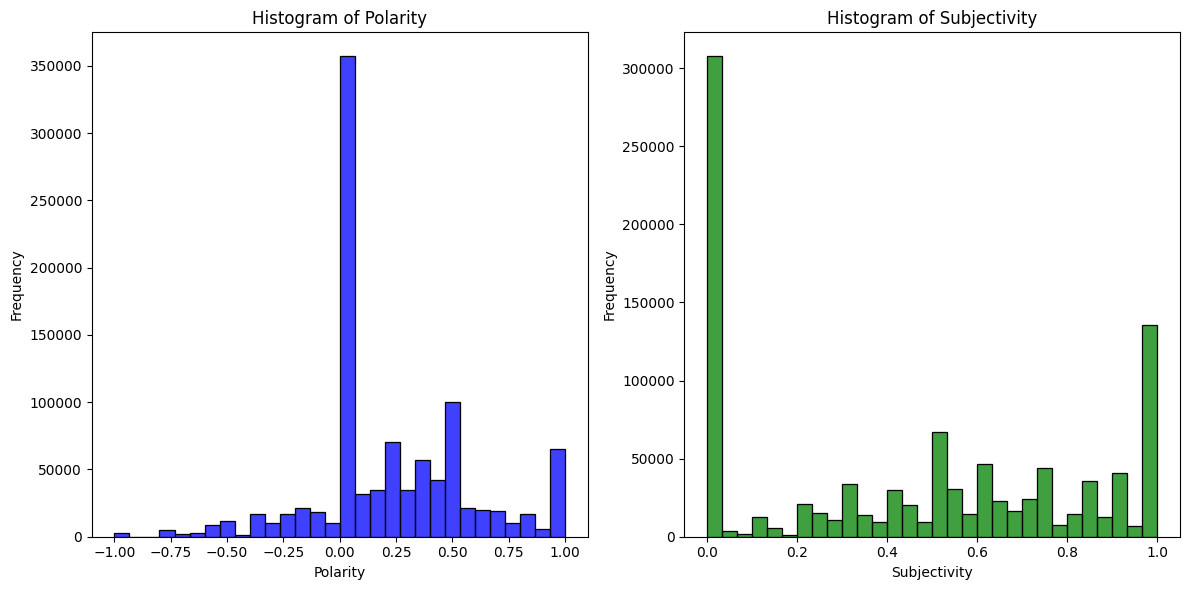

In [ ]:
# Setting up the figure size and subplots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.histplot(data['Polarity'], bins=30, kde=False, color='blue')
plt.title('Histogram of Polarity')
plt.xlabel('Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
sns.histplot(data['Subjectivity'], bins=30, kde=False, color='green')
plt.title('Histogram of Subjectivity')
plt.xlabel('Subjectivity')
plt.ylabel('Frequency')

# Show the plots
plt.tight_layout()
plt.show()


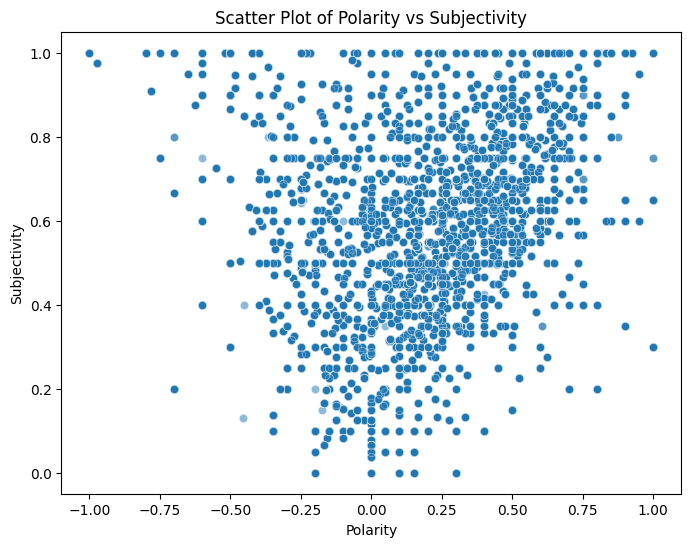

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Polarity', y='Subjectivity', data=data, alpha=0.5)
plt.title('Scatter Plot of Polarity vs Subjectivity')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')
plt.show()


 ⏬ **Tokenization** ▶  Bert

In [ ]:
import pandas as pd
from transformers import pipeline

# Initialize sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis")

# Ensure that all comments are strings and not None
data['Comment'] = data['Comment'].astype(str)

# Apply sentiment analysis and add the sentiment labels to the dataframe
data['Sentiment'] = data['Comment'].apply(lambda x: sentiment_pipeline(x)[0]['label'])


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


In [ ]:
from transformers import pipeline

# Initialize sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis")

# Apply sentiment analysis and add the sentiment labels to the dataframe
data['Sentiment'] = data['Comment'].apply(lambda x: sentiment_pipeline(x)[0]['label'])


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


KeyboardInterrupt: 

In [ ]:
# Assuming your data has a 'Sentiment' column now, map these to numerical labels
label_mapping = {'LABEL_0': 0, 'LABEL_1': 1, 'LABEL_2': 2}
data['sentiment_label'] = data['Sentiment'].map(label_mapping)

# Then follow with the encoding, dataset creation, and model training steps as previously described


In [ ]:
def analyze_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Return polarity: -1 (negative) to 1 (positive)


In [ ]:
# Replace NaN values with an empty string and convert all comments to strings
data['Coment'] = data['Coment'].fillna('').astype(str)

In [ ]:
data['sentiment_polarity'] = data['Coment'].apply(analyze_sentiment)


In [ ]:
import pandas as pd
from textblob import TextBlob

# Read data with the correct encoding
data_path = '/content/drive/My Drive/Merge.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Define the sentiment analysis function
def analyze_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Return polarity: -1 (negative) to 1 (positive)

# Ensure all comments are strings and replace NaN values
data['Coment'] = data['Coment'].fillna('').astype(str)

# Apply the sentiment analysis function
data['sentiment_polarity'] = data['Coment'].apply(analyze_sentiment)

# Display a few rows of the data
print(data[['Coment', 'sentiment_polarity']].head())

# Optional: Save the data with sentiment analysis to a new CSV file
data.to_csv('/content/drive/My Drive/Merge_with_Sentiments.csv', index=False)


                      Coment  sentiment_polarity
0     Truly gourmet quality                  0.0
1         Cant get enough                   0.0
2       Tastes like summer                   0.0
3     Incredibly flavorful                   0.9
4   Best pesto cheese ever                   1.0


In [ ]:
print(f"Total comments processed: {data['sentiment_polarity'].notna().sum()}")
print(f"Total comments in dataset: {len(data)}")


Total comments processed: 15189
Total comments in dataset: 15189


In [ ]:
data.to_csv('/content/drive/My Drive/Merge_with_Sentiments.csv', index=False)


In [ ]:
import pandas as pd
from textblob import TextBlob

# Load the dataset from a CSV file
data_path = '/content/drive/My Drive/Merge.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Initialize new columns for polarity and subjectivity scores
data['Polarity'] = 0.0
data['Subjectivity'] = 0.0

# Define a function to analyze sentiment of comments
def analyze_sentiment(text):
    """Analyzes the sentiment of the provided text using TextBlob and returns polarity and subjectivity."""
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply the sentiment analysis function to each comment in the DataFrame
for index, row in data.iterrows():
    polarity, subjectivity = analyze_sentiment(row['Coment'])
    data.at[index, 'Polarity'] = polarity
    data.at[index, 'Subjectivity'] = subjectivity

# Display the first few rows of the data to verify the changes
print(data.head())

# Optionally, save the updated DataFrame back to CSV
output_path = '/content/drive/My Drive/analyzed_data.csv'
data.to_csv(output_path, index=False, encoding='ISO-8859-1')


                      Coment  Like  Reply  Polarity  Subjectivity
0     Truly gourmet quality      0      0       0.0           0.0
1         Cant get enough       0      0       0.0           0.5
2       Tastes like summer       0      0       0.0           0.0
3     Incredibly flavorful       0      0       0.9           0.9
4   Best pesto cheese ever       0      0       1.0           0.3


In [ ]:

# our DataFrame
data = pd.DataFrame({
    'Comment': ["This is a good product", "This product is not good!"],
    'Like': [10, 2],
    'Reply': [10, 1],
    'cleaned_Comment': ["this is a good product", "this product is not good"]
})

# Adding new columns for polarity and subjectivity
data['Polarity'] = data['cleaned_Comment'].apply(lambda text: TextBlob(text).sentiment.polarity)
data['Subjectivity'] = data['cleaned_Comment'].apply(lambda text: TextBlob(text).sentiment.subjectivity)

# Display DataFrame with the new sentiment columns
print(data[['Comment', 'cleaned_Comment', 'Polarity', 'Subjectivity']])


                     Comment           cleaned_Comment  Polarity  Subjectivity
0     This is a good product    this is a good product      0.70           0.6
1  This product is not good!  this product is not good     -0.35           0.6


In [ ]:
from textblob import TextBlob

# Iterate over each row in the DataFrame
for index, row in data.iterrows():
    # Calculate polarity and subjectivity for each cleaned comment
    polarity = TextBlob(row['cleaned_Comment']).sentiment.polarity
    subjectivity = TextBlob(row['cleaned_Comment']).sentiment.subjectivity

    # Update DataFrame with the new values
    data.at[index, 'Polarity'] = polarity
    data.at[index, 'Subjectivity'] = subjectivity

# Display DataFrame with the new sentiment columns
print(data[['Comment', 'cleaned_Comment', 'Polarity', 'Subjectivity']])

                     Comment           cleaned_Comment  Polarity  Subjectivity
0     This is a good product    this is a good product      0.70           0.6
1  This product is not good!  this product is not good     -0.35           0.6


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


input_text = """
satisfied, joyful, delighted, trust, loyal, reliable, refreshing, pleasure, perfection, exceptional,
outstanding, impeccable, superb, supreme, delightful, unmatched, flawless, masterful, top-quality,
brilliance, satisfaction, pleasure, enjoyment, divine, bliss, gem, masterpiece, spectacular,
impressive, refreshing, satisfaction, content, ecstatic, euphoric, happiness, trustworthiness,
dependability, consistency, reliability, excellence, top-notch, wonderful, amazing, outstanding,
brilliant, fantastic
"""

# تبدیل متن به لیستی از جملات
sentences = input_text.split(',')

# ایجاد یک شی TF-IDF
vectorizer = TfidfVectorizer()

# محاسبه ماتریس TF-IDF
tfidf_matrix = vectorizer.fit_transform(sentences)

# استخراج کلمات کلیدی بر اساس مقادیر TF-IDF
feature_names = vectorizer.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1

# نمایش کلمات کلیدی به ترتیب اهمیت
keywords = [feature_names[i] for i in scores.argsort()[::-1]]
print("Keywords:", keywords)

Keywords: ['refreshing', 'satisfaction', 'outstanding', 'pleasure', 'top', 'divine', 'flawless', 'fantastic', 'exceptional', 'excellence', 'euphoric', 'enjoyment', 'ecstatic', 'wonderful', 'happiness', 'dependability', 'delightful', 'delighted', 'content', 'consistency', 'brilliant', 'brilliance', 'bliss', 'gem', 'joyful', 'impeccable', 'impressive', 'trustworthiness', 'trust', 'supreme', 'superb', 'spectacular', 'satisfied', 'reliable', 'reliability', 'perfection', 'masterpiece', 'masterful', 'loyal', 'unmatched', 'amazing', 'quality', 'notch']


In [ ]:
import pandas as pd
from textblob import TextBlob
from collections import Counter

# فرض می‌کنیم که داده‌ها در DataFrame به نام data ذخیره شده‌اند

# محاسبه نسبت تعاملات به دیدگاه‌ها
data['Engagement_Ratio'] = (data['Like'] + data['Reply']) / data['Coment'].apply(lambda x: len(x.split()))

# محاسبه طول هر کامنت
data['Content_Length'] = data['Coment'].apply(lambda x: len(x))

# محاسبه تنوع لغات در هر کامنت
def calculate_lexical_diversity(text):
    words = text.split()
    if len(words) > 0:
        return len(set(words)) / len(words)
    else:
        return 0  # برای جلوگیری از خطای تقسیم بر صفر

data['Lexical_Diversity'] = data['Coment'].apply(calculate_lexical_diversity)

# کلمات تکراری را حذف کنید
unique_keywords = set(keywords)

# تابع برای شمارش کلمات کلیدی در هر کامنت
def count_valid_keywords(text):
    words = text.lower().split()  # کوچک کردن حروف برای اطمینان از عدم حساسیت به بزرگی و کوچکی حروف
    return sum(word in unique_keywords for word in words)

data['Valid_Keywords'] = data['Coment'].apply(count_valid_keywords)

# محاسبه پلاریتی احساسات
data['Sentiment_Polarity'] = data['Coment'].apply(lambda x: TextBlob(x).sentiment.polarity)

# نمایش داده‌ها برای بررسی
print(data.head())



                      Coment  Like  Reply           cleaned_comments  \
0     Truly gourmet quality      0      0     truly gourmet quality    
1         Cant get enough       0      0         can t get enough     
2       Tastes like summer       0      0       tastes like summer     
3     Incredibly flavorful       0      0     incredibly flavorful     
4   Best pesto cheese ever       0      0   best pesto cheese ever     

   Engagement_Ratio  Content_Length  Lexical_Diversity  Valid_Keywords  \
0               0.0              23                1.0               1   
1               0.0              19                1.0               0   
2               0.0              21                1.0               0   
3               0.0              23                1.0               0   
4               0.0              25                1.0               0   

   Sentiment_Polarity  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.9  
4 

In [ ]:
# فرض بر این است که یک نظر با تعداد لایک و ریپلای بالا به عنوان معتبر تلقی شود
data['Label'] = (data['Like'] + data['Reply']).apply(lambda x: 1 if x > 10 else 0)

# اکنون می‌توانید داده‌ها را برای تقسیم به دو بخش آموزش و تست استفاده کنید
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, data['Label'], test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# پدینگ داده‌ها
padded_sequences = pad_sequences(sequences, maxlen=100)

# تقسیم داده‌ها به دو بخش آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, data['Label'], test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))


Epoch 1/10
190/190 [==============================] - 52s 275ms/step - loss: 0.0158 - accuracy: 0.9956 - val_loss: 0.0332 - val_accuracy: 0.9967
Epoch 2/10
190/190 [==============================] - 45s 235ms/step - loss: 0.0156 - accuracy: 0.9956 - val_loss: 0.0360 - val_accuracy: 0.9967
Epoch 3/10
190/190 [==============================] - 43s 227ms/step - loss: 0.0147 - accuracy: 0.9956 - val_loss: 0.0355 - val_accuracy: 0.9967
Epoch 4/10
190/190 [==============================] - 45s 236ms/step - loss: 0.0147 - accuracy: 0.9956 - val_loss: 0.0361 - val_accuracy: 0.9967
Epoch 5/10
190/190 [==============================] - 44s 229ms/step - loss: 0.0144 - accuracy: 0.9956 - val_loss: 0.0367 - val_accuracy: 0.9967
Epoch 6/10
190/190 [==============================] - 44s 233ms/step - loss: 0.0146 - accuracy: 0.9956 - val_loss: 0.0357 - val_accuracy: 0.9967
Epoch 7/10
190/190 [==============================] - 42s 224ms/step - loss: 0.0141 - accuracy: 0.9956 - val_loss: 0.0376 - val_ac

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy}')


95/95 [==============================] - 5s 55ms/step - loss: 0.0380 - accuracy: 0.9967
Test accuracy: 0.9967072606086731


In [ ]:
import pandas as pd
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# فرض می‌کنیم مسیر فایل شما به این شکل است
file_path = '/content/drive/My Drive/Merge.csv'
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# اطمینان حاصل کنید که تمام داده‌ها در ستون 'Coment' به رشته تبدیل شده‌اند
data['Coment'] = data['Coment'].astype(str)

# تعریف توکنایزر
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['Coment'])
sequences = tokenizer.texts_to_sequences(data['Coment'])

# پدینگ داده‌ها برای داشتن طول یکسان
padded_sequences = pad_sequences(sequences, maxlen=100)

# ادامه کد برای استفاده از امبدینگ‌ها یا سایر تحلیل‌ها


In [ ]:
# فرض بر این است که یک نظر با تعداد لایک و ریپلای بالا به عنوان معتبر تلقی شود
data['Label'] = (data['Like'] + data['Reply']).apply(lambda x: 1 if x > 10 else 0)

# اکنون می‌توانید داده‌ها را برای تقسیم به دو بخش آموزش و تست استفاده کنید
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, data['Label'], test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# پدینگ داده‌ها
padded_sequences = pad_sequences(sequences, maxlen=100)

# تقسیم داده‌ها به دو بخش آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, data['Label'], test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, Dense, Dropout
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

# فرض بر اینکه شما داده‌ها و امبدینگ‌های خود را آماده کرده‌اید
# ماتریس امبدینگ باید قبلاً ساخته شده باشد
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 100))  # فرض بر 100 بعدی بودن امبدینگ

model = Sequential()
model.add(Embedding(len(tokenizer.word_index) + 1, 100, weights=[embedding_matrix], trainable=False))
model.add(Bidirectional(LSTM(64, return_sequences=True)))  # استفاده از LSTM دوطرفه
model.add(Dropout(0.5))  # اضافه کردن لایه Dropout
model.add(GRU(32))  # اضافه کردن لایه GRU
model.add(Dense(1, activation='sigmoid'))  # برای طبقه‌بندی دودویی

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# تقسیم داده‌ها به دو بخش آموزشی و آزمایشی
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, data['Label'], test_size=0.2, random_state=42)

# آموزش مدل
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# ارزیابی مدل
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy}')


Epoch 1/10
190/190 [==============================] - 67s 309ms/step - loss: 0.0719 - accuracy: 0.9958 - val_loss: 0.0258 - val_accuracy: 0.9961
Epoch 2/10
190/190 [==============================] - 56s 297ms/step - loss: 0.0274 - accuracy: 0.9958 - val_loss: 0.0259 - val_accuracy: 0.9961
Epoch 3/10
190/190 [==============================] - 58s 308ms/step - loss: 0.0273 - accuracy: 0.9958 - val_loss: 0.0258 - val_accuracy: 0.9961
Epoch 4/10
190/190 [==============================] - 55s 291ms/step - loss: 0.0272 - accuracy: 0.9958 - val_loss: 0.0259 - val_accuracy: 0.9961
Epoch 5/10
190/190 [==============================] - 56s 293ms/step - loss: 0.0273 - accuracy: 0.9958 - val_loss: 0.0258 - val_accuracy: 0.9961
Epoch 6/10
190/190 [==============================] - 60s 318ms/step - loss: 0.0274 - accuracy: 0.9958 - val_loss: 0.0258 - val_accuracy: 0.9961
Epoch 7/10
190/190 [==============================] - 59s 313ms/step - loss: 0.0273 - accuracy: 0.9958 - val_loss: 0.0259 - val_ac

In [ ]:
!pip install keras-tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 1.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from keras_tuner import RandomSearch

def build_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=100))
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=256, step=32), return_sequences=True))
    model.add(Dropout(rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))


    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='keras_tune_example'
)


tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


Trial 10 Complete [00h 17m 25s]
val_accuracy: 0.9960500597953796

Best val_accuracy So Far: 0.9960500597953796
Total elapsed time: 03h 00m 24s
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          169300    
                                                                 
 lstm (LSTM)                 (None, 100, 192)          225024    
                                                                 
 dropout (Dropout)           (None, 100, 192)          0         
                                                                 
 dense (Dense)               (None, 100, 1)            193       
                                                                 
Total params: 394517 (1.50 MB)
Trainable params: 394517 (1.50 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
import numpy as np
import pandas as pd

# فرض کنید `embedding_matrix` شامل امبدینگ‌های شماست و `words` لیستی از کلمات مربوطه
embedding_matrix = np.random.rand(100, 50)  # 100 کلمه، هر کدام با 50 بعد
words = [f"word{i}" for i in range(100)]

# ذخیره امبدینگ‌ها
np.savetxt("vecs.tsv", embedding_matrix, delimiter="\t")

# ذخیره متن‌های مرتبط
pd.DataFrame(words).to_csv("meta.tsv", sep="\t", index=False, header=False)


In [ ]:
import numpy as np
import pandas as pd

# تولید داده‌های مثالی
num_words = 100  # تعداد کلمات
embedding_dim = 50  # بعد امبدینگ

# ساخت ماتریس امبدینگ تصادفی
embedding_matrix = np.random.rand(num_words, embedding_dim)

# لیست کلمات (فرض کنید این‌ها کلمات شما هستند)
words = [f"word_{i}" for i in range(num_words)]

# ذخیره امبدینگ‌ها
np.savetxt("vecs.tsv", embedding_matrix, delimiter="\t")

# ذخیره متادیتا
meta_df = pd.DataFrame(words, columns=['Words'])
meta_df.to_csv("meta.tsv", sep="\t", index=False, header=False)


In [ ]:
!ls


drive  meta.tsv  my_dir  sample_data  vecs.tsv


In [ ]:
words = ["actual_word1", "actual_word2", "actual_word3", ...]
meta_df = pd.DataFrame(words, columns=['Words'])
meta_df.to_csv("meta.tsv", sep="\t", index=False, header=False)


In [ ]:
import pandas as pd


num_words = 100
words = [f"word_{i}" for i in range(num_words)]

meta_df = pd.DataFrame(words, columns=['Words'])
meta_df.to_csv("meta.tsv", sep="\t", index=False, header=False)


In [ ]:

words = [satisfied, joyful, delighted, trust, loyal, reliable, refreshing, pleasure, perfection, exceptional,
outstanding, impeccable, superb, supreme, delightful, unmatched, flawless, masterful, top-quality,
brilliance, satisfaction, pleasure, enjoyment, divine, bliss, gem, masterpiece, spectacular,
impressive, refreshing, satisfaction, content, ecstatic, euphoric, happiness, trustworthiness,
dependability, consistency, reliability, excellence, top-notch, wonderful, amazing, outstanding,
brilliant, fantastic]
meta_df = pd.DataFrame(words, columns=['Words'])
meta_df.to_csv("meta.tsv", sep="\t", index=False, header=False)


In [ ]:
from google.colab import files

files.download('vecs.tsv')
files.download('meta.tsv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>